<a href="https://colab.research.google.com/github/Blenkzx/LINGUAGENS-DE-PROGRAMA-O/blob/main/EXERC%C3%8DCIO_PR%C3%81TICO_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

# Inserindo algumas linhas duplicadas intencionalmente
df_ecommerce = pd.concat([df_ecommerce, df_ecommerce.iloc[:10]], ignore_index=True)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")
df_ecommerce.head()

Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


## Tarefa 1: Limpeza e Preparação dos Dados

In [2]:
# 1. Verificar e remover linhas duplicadas
print(f"Número de linhas antes da remoção de duplicatas: {len(df_ecommerce)}")
df_ecommerce.drop_duplicates(inplace=True)
print(f"Número de linhas após a remoção de duplicatas: {len(df_ecommerce)}")

Número de linhas antes da remoção de duplicatas: 210
Número de linhas após a remoção de duplicatas: 200


In [3]:
# 2. Identificar colunas com valores nulos
print("\nValores nulos por coluna:")
print(df_ecommerce.isnull().sum())


Valores nulos por coluna:
ID_Cliente           0
Categoria            0
Valor_Gasto          0
Avaliacao_Compra    21
Idade_Cliente        0
dtype: int64


In [4]:
# 3. Preencher valores nulos da coluna 'Avaliacao_Compra' com a mediana
mediana_avaliacao = df_ecommerce['Avaliacao_Compra'].median()
df_ecommerce['Avaliacao_Compra'].fillna(mediana_avaliacao, inplace=True)
print(f"\nValores nulos em 'Avaliacao_Compra' preenchidos com a mediana: {mediana_avaliacao}")
print("Valores nulos após o preenchimento:")
print(df_ecommerce.isnull().sum())


Valores nulos em 'Avaliacao_Compra' preenchidos com a mediana: 4.0
Valores nulos após o preenchimento:
ID_Cliente          0
Categoria           0
Valor_Gasto         0
Avaliacao_Compra    0
Idade_Cliente       0
dtype: int64


/tmp/ipykernel_6148/1673713580.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['Avaliacao_Compra'].fillna(mediana_avaliacao, inplace=True)


## Tarefa 2: Comparação por Categoria (Boxplot com Seaborn)

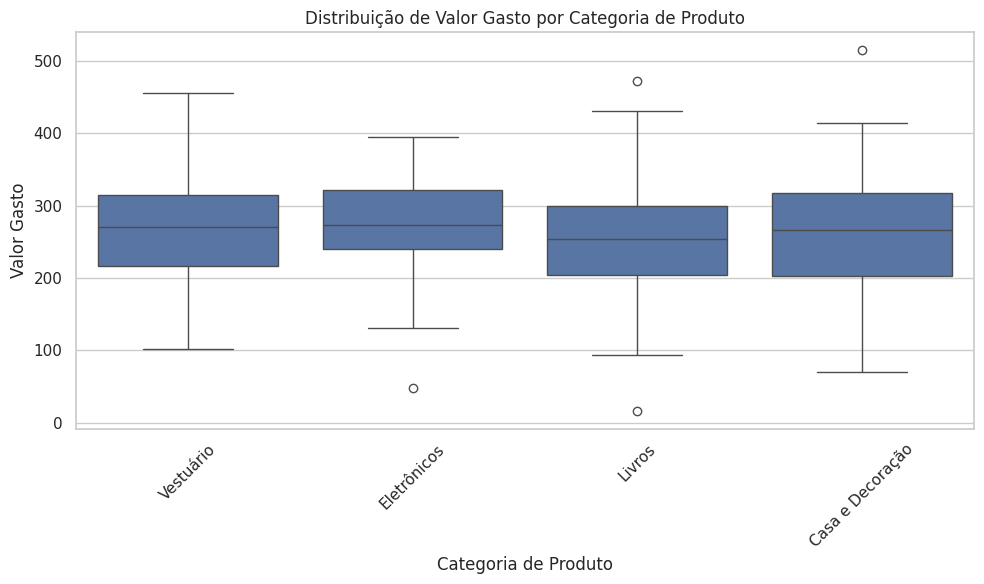

In [5]:
# 1. Criar um gráfico de Boxplot para comparar Valor_Gasto entre as Categorias
plt.figure(figsize=(10, 6))
sns.boxplot(x='Categoria', y='Valor_Gasto', data=df_ecommerce)
plt.title('Distribuição de Valor Gasto por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Valor Gasto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análise do Boxplot:

Observando o gráfico de boxplot acima, podemos identificar qual categoria possui a maior variação ou presença de outliers. A caixa mais longa indica maior variação, e pontos fora dos 'bigodes' são considerados outliers.

## Tarefa 3: Distribuição e Correlação

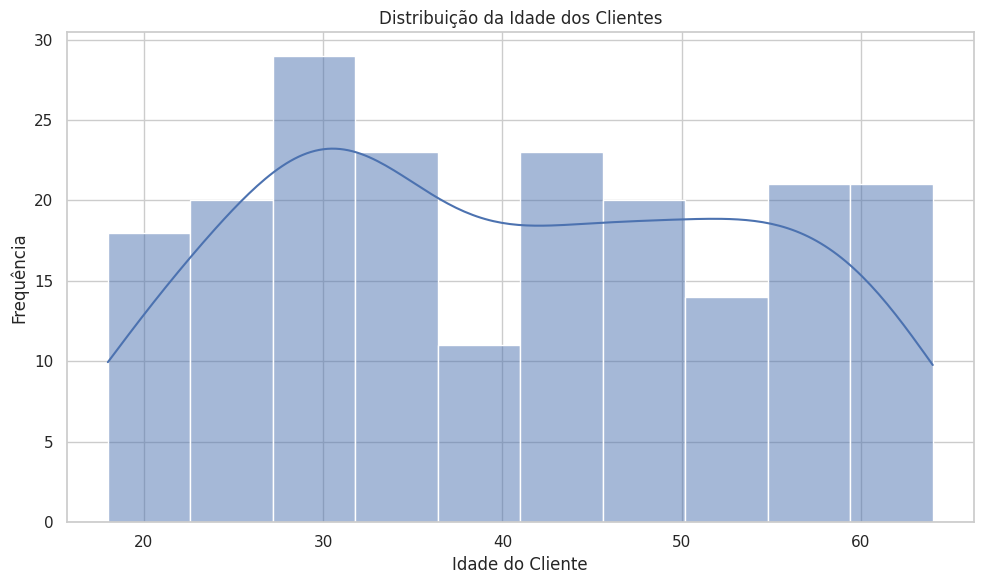

In [6]:
# 1. Criar um gráfico de Histograma com curva de densidade para Idade_Cliente
plt.figure(figsize=(10, 6))
sns.histplot(df_ecommerce['Idade_Cliente'], kde=True, bins=10)
# 2. Adicionar título e rótulos adequados
plt.title('Distribuição da Idade dos Clientes')
plt.xlabel('Idade do Cliente')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()